## 4 Evaluation Metrics for Classification

In the previous session we trained a model for predicting churn. How do we know if it's good?

## 4.1 Evaluation metrics: session overview

metric - function that compares the prediction with the actual values and outputs a single number that tells how good the predictions are

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [3]:
import os
import urllib.request

url = "https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv"
output_filename = "data_week3.csv"

#check if the file already exists
if not os.path.exists(output_filename):
    print(f"Downloading {output_filename}...")
    urllib.request.urlretrieve(url, output_filename)
    print("Download complete")
else:
    print(f"'{output_filename}' already exists. Skipping downloading")

'data_week3.csv' already exists. Skipping downloading


In [4]:
df = pd.read_csv(r"E:\Data Science\Data Camp\Practical Exam\machine-learning-zoomcamp-homework-\03-Classification\data_week3.csv")

df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.select_dtypes(include=['object', 'string']).columns)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')
    
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

df.churn = (df.churn == 'yes').astype(int)

In [5]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)
len(df_train), len(df_val), len(df_test)

df_train.reset_index(drop=True)
df_val.reset_index(drop=True)
df_test.reset_index(drop=True)

y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

del df_train['churn']
del df_val['churn']
del df_test['churn']

In [6]:
numerical = [
    'tenure',
    'monthlycharges',
    'totalcharges'
]

categorical = ['gender', 'seniorcitizen', 'partner', 'dependents',
        'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod'] 

In [7]:
dv = DictVectorizer(sparse=False)

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

model = LogisticRegression(max_iter=4500)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",4500
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [8]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

y_pred = model.predict_proba(X_val)[:, 1]
churn_decision = (y_pred >= 0.5)
(y_val == churn_decision).mean()

np.float64(0.8034066713981547)

## 4.2 Accuracy and dummy model

- Evaluate the model on different thresholds
- Check the accuracy of dummy baselines

In [9]:
churn_decision = (y_pred >= 0.45)
(y_val == churn_decision).mean()

np.float64(0.7913413768630234)

What happens when I change the 50% decision threshold?

In [10]:
thresholds = np.linspace(0, 1, 21)
thresholds

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

In [11]:
thresholds = np.linspace(0, 1, 21)

scores = []

for t in thresholds:
    churn_decision = (y_pred >= t)
    score = (y_val == churn_decision).mean()
    scores.append(score)
    print('%.2f %.3f'% (t, score))

0.00 0.274
0.05 0.513
0.10 0.608
0.15 0.661
0.20 0.703
0.25 0.735
0.30 0.758
0.35 0.766
0.40 0.782
0.45 0.791
0.50 0.803
0.55 0.803
0.60 0.796
0.65 0.789
0.70 0.766
0.75 0.742
0.80 0.729
0.85 0.726
0.90 0.726
0.95 0.726
1.00 0.726


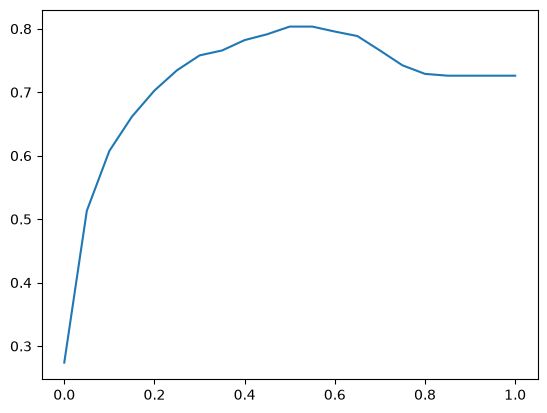

In [12]:
plt.plot(thresholds, scores)

In [13]:
from sklearn.metrics import accuracy_score

In [14]:
accuracy_score(y_val, (y_pred >= 0.5))

0.8034066713981547

In [15]:
thresholds = np.linspace(0, 1, 21)

scores = []

for t in thresholds:
    score = accuracy_score(y_val, y_pred >= t)
    print('%.2f %.3f'% (t, score))
    scores.append(score)
        

0.00 0.274
0.05 0.513
0.10 0.608
0.15 0.661
0.20 0.703
0.25 0.735
0.30 0.758
0.35 0.766
0.40 0.782
0.45 0.791
0.50 0.803
0.55 0.803
0.60 0.796
0.65 0.789
0.70 0.766
0.75 0.742
0.80 0.729
0.85 0.726
0.90 0.726
0.95 0.726
1.00 0.726


What if you predict everyone as not churning? What is the answer when t = 1? 73%

- the dummy model

In [16]:
from collections import Counter

In [17]:
Counter(y_pred >= 1.0)

Counter({np.False_: 1409})

- Our model is at 80%
- Prediction that no one will churn is 73%
- Therefore our model is 7% better than the prediction that no one will churn

In [18]:
Counter(y_val)

Counter({np.int64(0): 1023, np.int64(1): 386})

In [19]:
y_val.mean(), 1- y_val.mean()

(np.float64(0.2739531582682754), np.float64(0.7260468417317246))

27% are churning and 73% are not churning which is the same as the dummy

- The reason is the class imbalance. There are 3 times more non-churning clients to churning one
- Because of that, the prediction that no one will churn(73%), which is the majority, is pretty accurate and near our 80% prediction

## 4.3 Confusion Table

- Different types of errors and correct decisions
- Check the accuracy of dummy baselines

Translating This to Model Tuning
- Once you identify which paradigm your problem belongs to, you adjust your model's decision threshold (the probability cutoff for predicting a "1"):

- If it's a Pandemic Scenario: You lower the threshold (e.g., from 0.50 down to 0.15). The model becomes hyper-sensitive, flagging anything slightly suspicious. You'll get more false alarms, but you won't miss the real threats.

- If it's a Justice System Scenario: You raise the threshold (e.g., from 0.50 up to 0.85). The model only predicts "positive" when it is overwhelmingly certain.

In [20]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

actual_negative.sum(), actual_positive.sum()


(np.int64(1023), np.int64(386))

In [21]:
t=0.5

pred_positive = (y_pred >= t)
pred_negative = (y_pred < t)

In [22]:
tp = (pred_positive & actual_positive).sum()
tn = (pred_negative & actual_negative).sum()
fp = (pred_positive & actual_negative).sum()
fn = (pred_negative & actual_positive).sum()

tp, tn, fp, fn

(np.int64(212), np.int64(920), np.int64(103), np.int64(174))

In [23]:
confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])

confusion_matrix

array([[920, 103],
       [174, 212]])

-  174 - We have more false positives, we thought they would churn but didn't, therefore we lost money by sending them promotions
- 101 - False negatives who we do not send them discounts and they leave therefore we have lost revenue

In [24]:
(confusion_matrix/confusion_matrix.sum()).round(2)

array([[0.65, 0.07],
       [0.12, 0.15]])

## 4.4 Precision and Recall

- Precision is the fraction of positive predictions that are correct
- Recall is the fraction of positive predictions that are correct over the real positives


In [25]:
precision = tp /(tp + fp)
precision

np.float64(0.6730158730158731)

- I wrongly gave promotions to 103 people - 33%

In [38]:
recall = tp/(tp+fn)
recall

np.float64(0.5492227979274611)

- I missed out on 174 people who later churned (46%)
- I predicted 315 people would churn yet only 212 of 315 churned.
- I predicted 103 (fp) people had churned when infact they didn't but at the same time I missed out on a whole 174 (fn) who churned.
- I therefore failed to send promotional emails to 174 people who churned, and wasted promotions on 103 people who were not going to churn.

#### Therefore accuracy is not the best metrics to gauge our model when you look at precision and recall
- Accuracy can be misleading


## 4.5 ROC Curves

### TPR and FRP

### Random model

### Ideal model

## 4.6 ROC AUC

- Area under the ROC Curve - useful metric
- Interpretaion of AUC

## 4.7 Cross-Validation

- Evaluating the same model on different subsets of data
- Getting the average prediction and the spread within predictions

## 4.8 Summary

- Metric: A single number that describes the performance of a model
- Accuracy: Fraction of correct answers; sometimes misleading
- Precision and recall are less misleading when we have class imbalance
- ROC Curve: A way to evaluate the performance at all thresholds; okay to use with imbalance
- K-Fold CV: More reliable estimate for performance (mean + std)